여러분은 카지노의 슬롯머신 5개 중에서 가장 돈을 많이 벌 수 있는 머신을 찾아야 한다. 각 머신은 서로 다른 평균 보상을 가진다.

- 그 평균은 모름
- 직접 당겨보며 학습해야 함

### 1. 환경 설계

- 슬롯머신은 5개
- 각 머신의 서로 다른 평균 보상(예: 0.2, 0.5, 0.1, 0.8, 0.3)
- 보상은 확률적으로 지급(정규분포 또는 베르누이)

### 2. 전략 구현

- Random 전략
- Greedy 전략
- ε-greedy 전략(ε=0.1)

### 3. 실험 조건

- 총 1,000번 선택
- 누적 보상 기록
- 각 머신 선택 횟수 기록

### 4. 결과 분석

- 누적 보상 곡선
- 머신별 선택 비율
- ε값 변화 실험(0.1 vs 0.01)

### 5. 질문

- Greedy 전략은 왜 실패할 수 있나?
- ε값이 너무 크면 어떤 문제가 발생할 수 있나?
- ε값이 너무 작으면 어떤 문제가 발생하나?
- Exploration이 필요한 이유?

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

In [2]:
machineRewards = [200, 500, 100, 800, 300]
sds = [50, 150, 20, 300, 80]

# machineRewards = [200, 600, 100, 800, 300]
# sds = [50, 10, 20, 1000, 80]

In [3]:
all_histories = {}

### Random 전략

In [24]:
totalReward = 0.0
calcRewards = [0.0] * 5
counts = [0] * 5
history_random = []

for i in range(1000):
    randomNum = random.randint(0, 4)

    mu = machineRewards[randomNum]
    sigma = sds[randomNum]
    reward = np.random.normal(mu, sigma)

    counts[randomNum] += 1
    calcRewards[randomNum] += (reward - calcRewards[randomNum]) / counts[randomNum]

    totalReward += reward
    history_random.append(totalReward)

all_histories['Random'] = {'history': history_random, 'counts': counts.copy()}
print(f"최종 누적 보상: {totalReward}")
print(f"머신별 예상 평균(calcRewards): {calcRewards}")
print(f"머신별 선택 횟수: {counts}")

최종 누적 보상: 362547.4105348334
머신별 예상 평균(calcRewards): [203.15612145957624, 506.8466075812119, 99.70428444273368, 775.7688760797126, 297.98230860046624]
머신별 선택 횟수: [205, 197, 220, 181, 197]


### Greedy 전략

In [25]:
totalReward = 0.0
calcRewards = [0.0] * 5
counts = [0] * 5
history_greedy = []

for i in range(1):
    for j in range(5):
        mu = machineRewards[j]
        sigma = sds[j]
        reward = np.random.normal(mu, sigma)

        counts[j] += 1
        calcRewards[j] += (reward - calcRewards[j]) / counts[j]

        totalReward += reward
        history_greedy.append(totalReward)

for i in range(900):
    maxIndex = calcRewards.index(max(calcRewards))

    mu = machineRewards[maxIndex]
    sigma = sds[maxIndex]
    reward = np.random.normal(mu, sigma)

    counts[maxIndex] += 1
    calcRewards[maxIndex] += (reward - calcRewards[maxIndex]) / counts[maxIndex]

    totalReward += reward
    history_greedy.append(totalReward)

all_histories['Greedy'] = {'history': history_greedy, 'counts': counts.copy()}
print(f"최종 누적 보상: {totalReward}")
print(f"머신별 예상 평균(calcRewards): {calcRewards}")
print(f"머신별 선택 횟수: {counts}")

최종 누적 보상: 450770.0676703554
머신별 예상 평균(calcRewards): [182.23333928508902, 499.25838365734216, 76.02144697024286, 328.4205512005752, 351.58865763452883]
머신별 선택 횟수: [1, 901, 1, 1, 1]


### $\epsilon$-greedy 전략 (0.1)

In [26]:
totalReward = 0.0
calcRewards = [0.0] * 5
counts = [0] * 5
epsilon = 0.1
history_eps_01 = []

for i in range(20):
    for j in range(5):
        mu = machineRewards[j]
        sigma = sds[j]
        reward = np.random.normal(mu, sigma)

        counts[j] += 1
        calcRewards[j] += (reward - calcRewards[j]) / counts[j]

        totalReward += reward
        history_eps_01.append(totalReward)

for i in range(900):
    if random.random() < epsilon:
        selectedIndex = random.randint(0, 4)
    else:
        selectedIndex = calcRewards.index(max(calcRewards))

    mu = machineRewards[selectedIndex]
    sigma = sds[selectedIndex]
    reward = np.random.normal(mu, sigma)

    counts[selectedIndex] += 1
    calcRewards[selectedIndex] += (reward - calcRewards[selectedIndex]) / counts[selectedIndex]

    totalReward += reward
    history_eps_01.append(totalReward)

all_histories['eps_0.1'] = {'history': history_eps_01, 'counts': counts.copy()}
print(f"최종 누적 보상: {totalReward}")
print(f"머신별 예상 평균(calcRewards): {calcRewards}")
print(f"머신별 선택 횟수: {counts}")

최종 누적 보상: 728488.1740842998
머신별 예상 평균(calcRewards): [203.5806878165242, 433.0679208455338, 103.8615697191223, 811.9117795352772, 288.0210317043493]
머신별 선택 횟수: [44, 32, 37, 852, 35]


### $\epsilon$-greedy 전략 (0.01)

In [27]:
totalReward = 0.0
calcRewards = [0.0] * 5
counts = [0] * 5
epsilon = 0.01
history_eps_001 = []

for i in range(20):
    for j in range(5):
        mu = machineRewards[j]
        sigma = sds[j]
        reward = np.random.normal(mu, sigma)

        counts[j] += 1
        calcRewards[j] += (reward - calcRewards[j]) / counts[j]

        totalReward += reward
        history_eps_001.append(totalReward)

for i in range(900):
    if random.random() < epsilon:
        selectedIndex = random.randint(0, 4)
    else:
        selectedIndex = calcRewards.index(max(calcRewards))

    mu = machineRewards[selectedIndex]
    sigma = sds[selectedIndex]
    reward = np.random.normal(mu, sigma)

    counts[selectedIndex] += 1
    calcRewards[selectedIndex] += (reward - calcRewards[selectedIndex]) / counts[selectedIndex]

    totalReward += reward
    history_eps_001.append(totalReward)

all_histories['eps_0.01'] = {'history': history_eps_001, 'counts': counts.copy()}
print(f"최종 누적 보상: {totalReward}")
print(f"머신별 예상 평균(calcRewards): {calcRewards}")
print(f"머신별 선택 횟수: {counts}")

최종 누적 보상: 733555.9079177886
머신별 예상 평균(calcRewards): [194.20604291997816, 467.3130185495367, 95.73785815558949, 780.6182536591988, 316.0270128225554]
머신별 선택 횟수: [23, 22, 22, 908, 25]


### 결과 분석

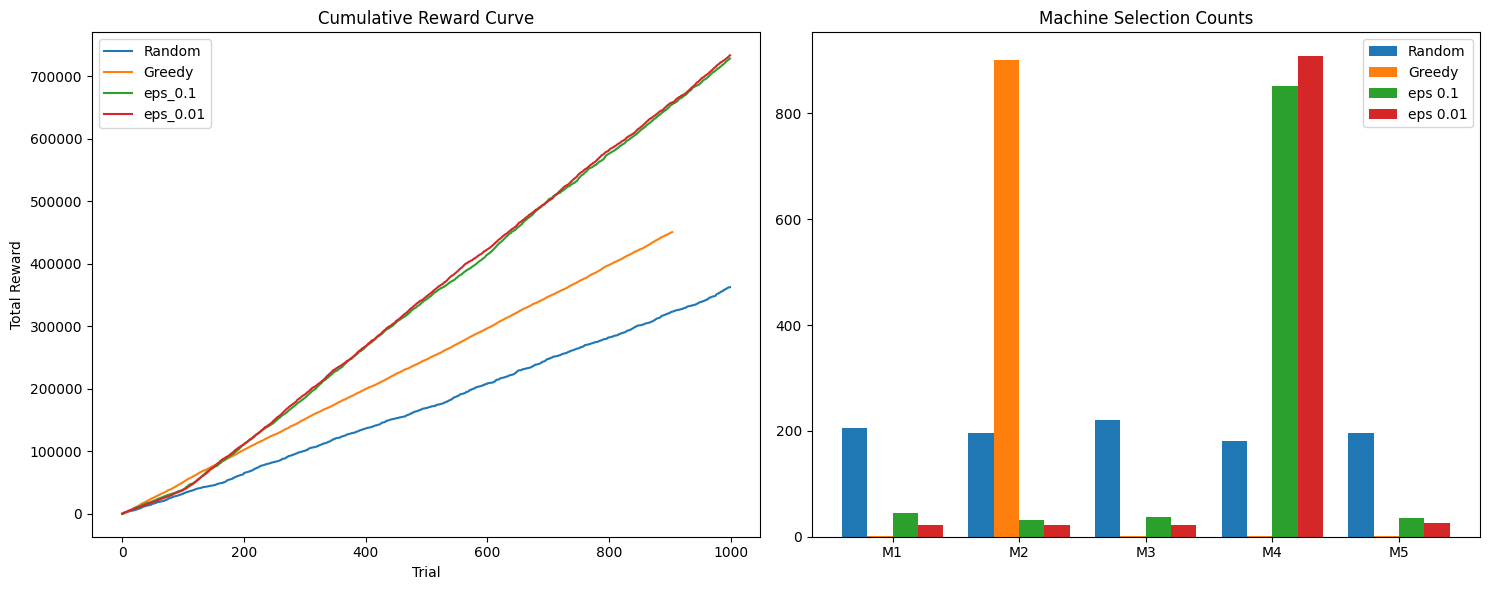

In [28]:
plt.figure(figsize=(15, 6))

# 1. 누적 보상 곡선
plt.subplot(1, 2, 1)
for label, data in all_histories.items():
    plt.plot(data['history'], label=label)
plt.title("Cumulative Reward Curve")
plt.xlabel("Trial")
plt.ylabel("Total Reward")
plt.legend()

# 2. 머신별 선택 비율 (최종 선택 횟수)
plt.subplot(1, 2, 2)
x = np.arange(5)
width = 0.2
plt.bar(x - 1.5*width, all_histories['Random']['counts'], width, label='Random')
plt.bar(x - 0.5*width, all_histories['Greedy']['counts'], width, label='Greedy')
plt.bar(x + 0.5*width, all_histories['eps_0.1']['counts'], width, label='eps 0.1')
plt.bar(x + 1.5*width, all_histories['eps_0.01']['counts'], width, label='eps 0.01')
plt.xticks(x, [f"M{i+1}" for i in range(5)])
plt.title("Machine Selection Counts")
plt.legend()

plt.tight_layout()
plt.show()

### 질문
- Greedy 전략은 왜 실패할 수 있나?
> Greedy 전략은 처음에 운 좋게 표준편차로 인해 평균이 제일 높은 값이 낮게 나올 가능성이 있기 떄문에 그런 값을 나쁘게 보고 그 기계로 다신 안돌릴 가능성이 있기 때문이다.
- ε값이 너무 크면 어떤 문제가 발생할 수 있나?
> 엡실론 값이 크면 클수록 Random 방식과 다를 바가 없다. 평균적으로 가장 좋은 보상이 있는 친구를 계속 공략해야 가장 높은 보상을 얻을 수 있지만 엡실론 값이 높으면 탐색을 계속하게 되기 때문이다.
- ε값이 너무 작으면 어떤 문제가 발생하나?
> 엡실론 값이 작을수록 Greedy 방식과 다를 바가 없다. 처음에 답변했던 거처럼 실패할 수 있기 때문이다. 탐색을 다시 할 기회를 얻기 힘들기 떄문이다.
- Exploration이 필요한 이유?
> 사람도 한 부분만 보고 완벽하게 그 사람을 이해할 수 없는 것처럼 슬롯머신도 한 번 당겨봤다고 그 친구가 최고의 슬롯머신이라고 확정할 수 없기 떄문이다.